# Assignment: Video Quality Inference

To this point in the class, you have learned various techniques for leading and analyzing packet captures of various types, generating features from those packet captures, and training and evaluating models using those features.

In this assignment, you will put all of this together, using a network traffic trace to train a model to automatically infer video quality of experience from a labeled traffic trace.

## Part 1: Warmup

The first part of this assignment builds directly on the hands-on activities but extends them slightly.

### Extract Features from the Network Traffic

Load the `netflix.pcap` file, which is a packet trace that includes network traffic. 

Click [here](https://github.com/noise-lab/ml-systems/blob/main/docs/notebooks/data/netflix.pcap) to download `netflix.pcap`.


In [1]:
from scapy.all import rdpcap, wrpcap

packets = rdpcap('data/netflix.pcap')

### Identifying the Service Type

Use the DNS traffic to filter the packet trace for Netflix traffic.

In [ ]:
from netml.pparser.parser import PCAP

NF_DOMAINS = (["nflxvideo",
              "netflix",
              "nflxso",
              "nflxext"])

filtered = []
for pkt in packets:
    if 'DNS' in pkt and pkt['DNS'].qd and pkt['DNS'].qd.qname.decode():
        qname = pkt['DNS'].qd.qname.decode()
        if any(qname.find(domain) for domain in NF_DOMAINS):
            filtered.append(pkt)

# print(filtered)
wrpcap('data/filtered_netflix.pcap', filtered)
pcap = PCAP('data/filtered_netflix.pcap', verbose=1)

### Generate Statistics

Generate statistics and features for the Netflix traffic flows. Use the `netml` library or any other technique that you choose to generate a set of features that you think would be good features for your model. 

In [ ]:
pcap.pcap2flows()
pcap.flow2features('STATS', fft=False, header=False)
stats_features = pcap.features

print(stats_features)

pcap_file: data/filtered_netflix.pcap
[[4.86705466e+02 1.84916764e-02 2.06284924e+00 1.11555556e+02
  3.56093343e+01 9.00000000e+01 9.20000000e+01 9.70000000e+01
  9.00000000e+01 1.78000000e+02 9.00000000e+00 1.00400000e+03]
 [4.86123808e+02 5.55414064e-02 6.47777366e+00 1.16629630e+02
  1.83689516e+01 1.04000000e+02 1.10000000e+02 1.17000000e+02
  9.80000000e+01 1.49000000e+02 2.70000000e+01 3.14900000e+03]
 [1.34391201e+01 2.97638535e-01 2.32158057e+01 7.80000000e+01
  0.00000000e+00 7.80000000e+01 7.80000000e+01 7.80000000e+01
  7.80000000e+01 7.80000000e+01 4.00000000e+00 3.12000000e+02]
 [3.89531994e+02 2.56718322e-02 2.26425560e+00 8.82000000e+01
  7.11055553e+00 8.10000000e+01 9.00000000e+01 9.20000000e+01
  7.80000000e+01 9.70000000e+01 1.00000000e+01 8.82000000e+02]
 [4.14018431e+01 1.44921085e-01 1.86948199e+01 1.29000000e+02
  0.00000000e+00 1.29000000e+02 1.29000000e+02 1.29000000e+02
  1.29000000e+02 1.29000000e+02 6.00000000e+00 7.74000000e+02]
 [2.29038596e+00 1.30982291

**Write a brief justification for the features that you have chosen.**

I consider the features that are relevant for video quality to be those that are related to the stability of packet/byte flows throughout the duration of the video. 

This leaves IAT and STATS as the two best candidates for feature extraction from the pcap (using netml, anyways), but here I've chosen STATS, as it is a set of many statistics that includes flow duration, packets and bytes per second, as well as summary statistics, making it a bit more insightful than purely the IAT of packets. 

In inferring video quality, we care about stability and consistency in packet delivery, so using features that cover the entirety of the flow and provide some statistical evidence seems most appropriate.

### Inferring Segment downloads

In addition to the features that you could generate using the `netml` library or similar, add to your feature vector a "segment downloads rate" feature, which indicates the number of video segments downloaded for a given time window.

Note: If you are using the `netml` library, generating features with `SAMP` style options may be useful, as this option gives you time windows, and you can then simply add the segment download rate to that existing dataframe.

In [83]:
import numpy as np

pcap.flow2features('SAMP_SIZE', fft=False, header=False)
sampnum_features = pcap.features
print(sampnum_features)

np.concatenate((stats_features, sampnum_features), axis=1)

[[ 90.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.]
 [306.  98.   0.   0.  98.   0.   0.   0.   0. 117.   0.   0.   0.   0.]
 [156.  78.   0.  78.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.]
 [ 90.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.]
 [387.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0. 129. 258.   0.]
 [243.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.]
 [202.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.]
 [356.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.]]


array([[4.86705466e+02, 1.84916764e-02, 2.06284924e+00, 1.11555556e+02,
        3.56093343e+01, 9.00000000e+01, 9.20000000e+01, 9.70000000e+01,
        9.00000000e+01, 1.78000000e+02, 9.00000000e+00, 1.00400000e+03,
        9.00000000e+01, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00],
       [4.86123808e+02, 5.55414064e-02, 6.47777366e+00, 1.16629630e+02,
        1.83689516e+01, 1.04000000e+02, 1.10000000e+02, 1.17000000e+02,
        9.80000000e+01, 1.49000000e+02, 2.70000000e+01, 3.14900000e+03,
        3.06000000e+02, 9.80000000e+01, 0.00000000e+00, 0.00000000e+00,
        9.80000000e+01, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 1.17000000e+02, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00],
       [1.34391201e+01, 2.97638535e-01, 2.32158057e+01

## Part 2: Video Quality Inference

You will now load the complete video dataset from a previous study to train and test models based on these features to automatically infer the quality of a streaming video flow.

For this part of the assignment, you will need two pickle files, which we provide for you by running the code below:

```

!gdown 'https://drive.google.com/uc?id=1N-Cf4dJ3fpak_AWgO05Fopq_XPYLVqdS' -O netflix_session.pkl
!gdown 'https://drive.google.com/uc?id=1PHvEID7My6VZXZveCpQYy3lMo9RvMNTI' -O video_dataset.pkl

```

### Load the File

Load the video dataset pickle file.

In [125]:
from netml.utils.tool import load_data

df = load_data('data/netflix_dataset.pkl')
df.head()

,10_EWMA_chunksizes,10_avg_chunksize,10_chunksizes_50,10_chunksizes_50R,10_chunksizes_75,10_chunksizes_75R,10_chunksizes_85,10_chunksizes_85R,10_chunksizes_90,10_chunksizes_90R,...,userTwoRetransmit,userUrgFlags,userXRetransmit,userZeroRetransmit,service,startup3.3,startup6.6,startup5,startup10,startup_mc
208,"[[4380.0], [4380.0], [19682.095238095237], [23...",148947.1,43473.0,43473.0,185098.0,185098.0,361832.3,361832.3,461040.2,461040.2,...,0.0,0,0.108730,0.557937,netflix,False,False,False,False,12.0
209,"[[179260.0], [130204.0], [49666.09523809524], ...",91984.2,101882.0,101882.0,122323.0,122323.0,159843.4,159843.4,181011.8,181011.8,...,0.0,0,0.116865,0.549802,netflix,False,False,False,False,12.0
210,"[[317962.0], [83192.4], [170850.7619047619], [...",147725.0,111373.0,111373.0,224157.0,224157.0,286280.0,286280.0,325845.8,325845.8,...,0.0,0,0.126852,0.539815,netflix,False,False,False,False,12.0
211,"[[396800.0], [98961.6], [246910.09523809524], ...",246420.6,297522.0,297522.0,330737.5,330737.5,361030.7,361030.7,378404.0,378404.0,...,0.0,0,0.186111,0.480556,netflix,False,False,False,False,12.0
212,"[[325264.0], [331102.4], [365584.38095238095],...",336681.0,354461.0,354461.0,399719.5,399719.5,409866.3,409866.3,414060.0,414060.0,...,0.0,0,0.194444,0.472222,netflix,False,False,False,False,12.0


### Clean the File

1. The dataset contains video resolutions that are not valid. Remove entries in the dataset that do not contain a valid video resolution. Valid resolutions are 240, 360, 480, 720, 1080.

In [126]:
valid_res = {240, 360, 480, 720, 1080}

df = df[df['resolution'].isin(valid_res)]
df

,10_EWMA_chunksizes,10_avg_chunksize,10_chunksizes_50,10_chunksizes_50R,10_chunksizes_75,10_chunksizes_75R,10_chunksizes_85,10_chunksizes_85R,10_chunksizes_90,10_chunksizes_90R,...,userTwoRetransmit,userUrgFlags,userXRetransmit,userZeroRetransmit,service,startup3.3,startup6.6,startup5,startup10,startup_mc
208,"[[4380.0], [4380.0], [19682.095238095237], [23...",148947.1,43473.0,43473.0,185098.0,185098.0,361832.3,361832.3,461040.2,461040.2,...,0.0,0,0.108730,0.557937,netflix,False,False,False,False,12.0
209,"[[179260.0], [130204.0], [49666.09523809524], ...",91984.2,101882.0,101882.0,122323.0,122323.0,159843.4,159843.4,181011.8,181011.8,...,0.0,0,0.116865,0.549802,netflix,False,False,False,False,12.0
210,"[[317962.0], [83192.4], [170850.7619047619], [...",147725.0,111373.0,111373.0,224157.0,224157.0,286280.0,286280.0,325845.8,325845.8,...,0.0,0,0.126852,0.539815,netflix,False,False,False,False,12.0
211,"[[396800.0], [98961.6], [246910.09523809524], ...",246420.6,297522.0,297522.0,330737.5,330737.5,361030.7,361030.7,378404.0,378404.0,...,0.0,0,0.186111,0.480556,netflix,False,False,False,False,12.0
212,"[[325264.0], [331102.4], [365584.38095238095],...",336681.0,354461.0,354461.0,399719.5,399719.5,409866.3,409866.3,414060.0,414060.0,...,0.0,0,0.194444,0.472222,netflix,False,False,False,False,12.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200633,"[[566340.0], [269408.8], [527273.3333333334], ...",498288.4,562720.0,562720.0,587584.0,587584.0,601268.3,601268.3,616109.6,616109.6,...,0.0,0,0.027778,0.055556,netflix,False,True,True,True,4.0
200634,"[[589034.0], [533811.6], [571466.7619047619], ...",495682.8,545831.0,545831.0,587584.0,587584.0,606287.6,606287.6,623059.4,623059.4,...,0.0,0,0.062500,0.104167,netflix,False,True,True,True,4.0
200635,"[[195178.0], [486315.6], [641802.380952381], [...",558961.0,555966.0,555966.0,671688.5,671688.5,730233.1,730233.1,778571.2,778571.2,...,0.0,0,0.027778,0.055556,netflix,False,True,True,True,4.0
200636,"[[476568.0], [521363.2], [272839.61904761905],...",599166.8,584205.0,584205.0,744688.5,744688.5,866199.1,866199.1,937127.8,937127.8,...,0.0,0,0.062500,0.104167,netflix,False,True,True,True,4.0


2. The file also contains columns that are unnecessary (in fact, unhelpful!) for performing predictions. Identify those columns, and remove them.

In [211]:
to_drop = [col for col, dtype in df.dtypes.to_dict().items() if col.find('_id') != -1 \
           or col == 'ads' \
           or col == 'quality' \
           or (dtype == 'object' and col != 'resolution')]
df = df.drop(columns=to_drop)
df

,10_avg_chunksize,10_chunksizes_50,10_chunksizes_50R,10_chunksizes_75,10_chunksizes_75R,10_chunksizes_85,10_chunksizes_85R,10_chunksizes_90,10_chunksizes_90R,10_max_chunksize,...,userThroughput,userTwoRetransmit,userUrgFlags,userXRetransmit,userZeroRetransmit,startup3.3,startup6.6,startup5,startup10,startup_mc
208,148947.1,43473.0,43473.0,185098.0,185098.0,361832.3,361832.3,461040.2,461040.2,539882,...,0.0,0.0,0,0.108730,0.557937,False,False,False,False,12.0
209,91984.2,101882.0,101882.0,122323.0,122323.0,159843.4,159843.4,181011.8,181011.8,196778,...,0.0,0.0,0,0.116865,0.549802,False,False,False,False,12.0
210,147725.0,111373.0,111373.0,224157.0,224157.0,286280.0,286280.0,325845.8,325845.8,396800,...,0.0,0.0,0,0.126852,0.539815,False,False,False,False,12.0
211,246420.6,297522.0,297522.0,330737.5,330737.5,361030.7,361030.7,378404.0,378404.0,396800,...,0.0,0.0,0,0.186111,0.480556,False,False,False,False,12.0
212,336681.0,354461.0,354461.0,399719.5,399719.5,409866.3,409866.3,414060.0,414060.0,438000,...,0.0,0.0,0,0.194444,0.472222,False,False,False,False,12.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200633,498288.4,562720.0,562720.0,587584.0,587584.0,601268.3,601268.3,616109.6,616109.6,690392,...,0.0,0.0,0,0.027778,0.055556,False,True,True,True,4.0
200634,495682.8,545831.0,545831.0,587584.0,587584.0,606287.6,606287.6,623059.4,623059.4,690392,...,0.0,0.0,0,0.062500,0.104167,False,True,True,True,4.0
200635,558961.0,555966.0,555966.0,671688.5,671688.5,730233.1,730233.1,778571.2,778571.2,1020538,...,0.0,0.0,0,0.027778,0.055556,False,True,True,True,4.0
200636,599166.8,584205.0,584205.0,744688.5,744688.5,866199.1,866199.1,937127.8,937127.8,1020538,...,0.0,0.0,0,0.062500,0.104167,False,True,True,True,4.0


**Briefly explain why you removed those columns.**

We disregard columns related to an ID or other identifying string, since we are not concerned with specific subjects. We also remove the 'ads' columns, since it is not relevant to video quality whether or not the video contained ads, as well as the 'quality' column, which only gives us a binary 'good/bad' classification, when we will be predicting resolution instead.

Two more columns were removed--namely, the 'service' and '10_EWMA_chunksizes' columns--as they were both unrelevant and also introduced unnecessary complications in creating a clean feature vector due to their types (i.e. '10_EWMA_chunksizes being a list). 

### Prepare Your Data

Prepare your data matrix, determine your features and labels, and perform a train-test split on your data.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

RANDOM_STATE = 42
TEST_SIZE = 0.33

target = df['resolution'].to_numpy()
features = df.drop(columns=['resolution']).to_numpy(dtype=object)

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=TEST_SIZE, random_state=RANDOM_STATE)

# impute missing values (nan) for SVC
imp = SimpleImputer(strategy='mean')
X_train = imp.fit_transform(X_train)
X_test = imp.fit_transform(X_test)

print(f'X_train.shape: {X_train.shape}, X_test.shape: {X_test.shape}, y_train.shape: {y_train.shape}, '
      f'y_test.shape: {y_test.shape}')

X_train.shape: (33331, 242), X_test.shape: (16417, 242), y_train.shape: (33331,), y_test.shape: (16417,)


### Train and Tune Your Model

1. Select a model of your choice.
2. Train the model using your training data.

In [221]:
from netml.ndm.model import MODEL
from sklearn.svm import SVC

model = SVC(kernel='rbf', random_state=RANDOM_STATE)
model.name = 'SVC'
ndm = MODEL(model, score_metric='accuracy', random_state=RANDOM_STATE)

ndm.train(X_train, y_train)
ndm.test(X_test, y_test)

### Tune Your Model

Perform hyperparameter tuning to find optimal parameters for your model.

In [222]:
from sklearn import metrics

best = (-1, -1)  # (accuracy, C)

for C in [0.1, 1, 10, 100]:
    model = SVC(kernel='rbf', C=C, random_state=RANDOM_STATE)
    model.name = f'SVC_C_{C}'
    ndm = MODEL(model, score_metric='accuracy', random_state=RANDOM_STATE)

    ndm.train(X_train, y_train)
    acc = metrics.accuracy_score(y_test, ndm.model.predict(X_test))
    print(f'C: {C}, acc: {acc}')
    best = max(best, (acc, C))

print(f'Best score: {best[0]}, achieved with C={best[1]}')

C: 0.1, acc: 0.592800146189925
C: 1, acc: 0.6822805628312115
C: 10, acc: 0.6822805628312115
C: 100, acc: 0.6822805628312115
Best score: 0.6822805628312115, achieved with C=100


### Evaluate Your Model

Evaluate your model accuracy according to the following metrics:

1. Accuracy
2. F1 Score
3. Confusion Matrix
4. ROC/AUC

In [226]:
acc = metrics.accuracy_score(y_test, ndm.model.predict(X_test))
f1 = metrics.f1_score(y_test, ndm.model.predict(X_test), average=None)
conf_mat = metrics.confusion_matrix(y_test, ndm.model.predict(X_test))

print(f'Accuracy: {best[0]}, \
      \nF1-score: {f1}, \
      \n Confusion Matrix: {conf_mat}')

Accuracy: 0.6822805628312115,       
F1-score: [0.         0.         0.79486022 0.         0.91815162],       
 Confusion Matrix: [[   0    0  555    0    5]
 [   0    0 1481    0    6]
 [   0    0 9681    0   51]
 [   0    0 2909    0  208]
 [   0    0    1    0 1520]]


In [231]:
# for the roc_auc_score, we require a little more data processing
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score

y_test_binarized = label_binarize(y_test, classes=[240, 360, 480, 720, 1080])
y_score = ndm.model.decision_function(X_test)
roc_auc = roc_auc_score(y_test_binarized, y_score, multi_class='ovr', average='macro')

print(f'ROC-AUC Score: {roc_auc}')


ROC-AUC Score: 0.7334295204025495


## Part 3: Predict the Ongoing Resolution of a Real Netflix Session

Now that you have your model, it's time to put it in practice!

Use a preprocessed Netflix video session to infer **and plot** the resolution at 10-second time intervals.

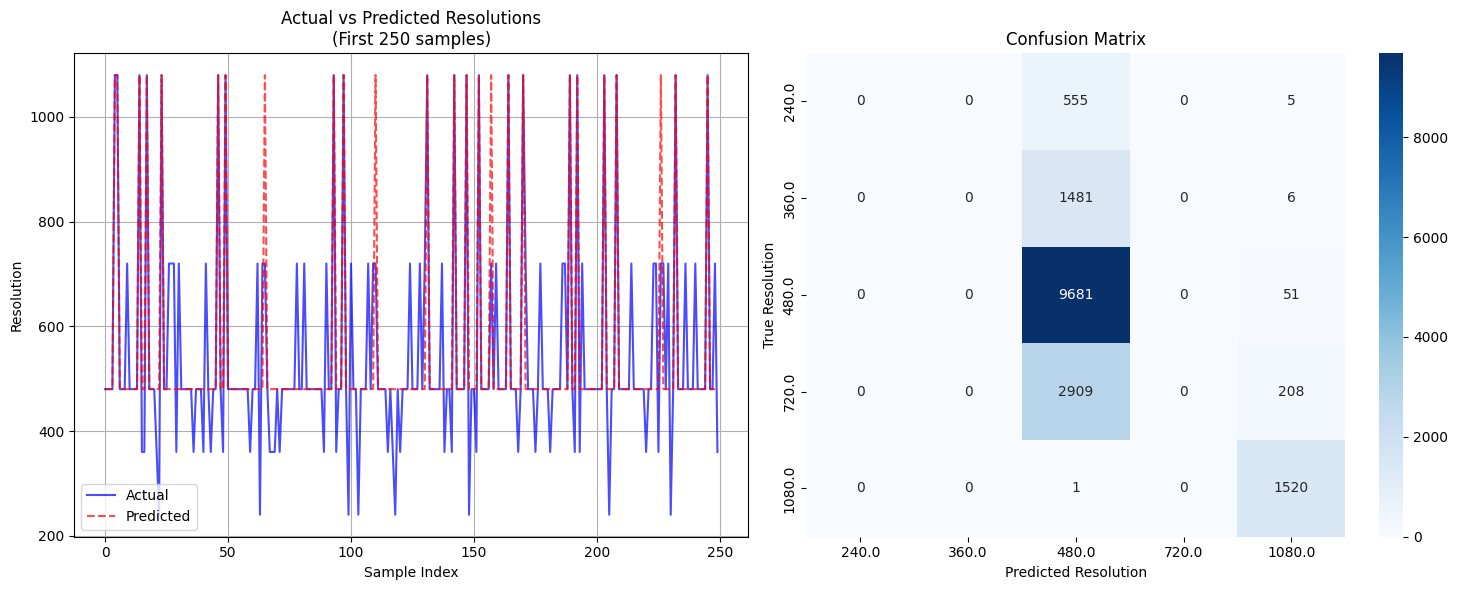


Classification Report:
              precision    recall  f1-score   support

       240.0       0.00      0.00      0.00       560
       360.0       0.00      0.00      0.00      1487
       480.0       0.66      0.99      0.79      9732
       720.0       0.00      0.00      0.00      3117
      1080.0       0.85      1.00      0.92      1521

    accuracy                           0.68     16417
   macro avg       0.30      0.40      0.34     16417
weighted avg       0.47      0.68      0.56     16417



/Users/xingr21/cs25422/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/xingr21/cs25422/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/xingr21/cs25422/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result)

In [234]:
import matplotlib.pyplot as plt
import seaborn as sns

y_pred = ndm.model.predict(X_test)

plt.figure(figsize=(15, 6))

samp_size = 250

# Plot 1: Line plot of actual vs predicted values
plt.subplot(1, 2, 1)
plt.plot(y_test[:samp_size], 'b-', label='Actual', alpha=0.7)
plt.plot(y_pred[:samp_size], 'r--', label='Predicted', alpha=0.7)
plt.xlabel('Sample Index')
plt.ylabel('Resolution')
plt.title(f'Actual vs Predicted Resolutions\n(First {samp_size} samples)')
plt.legend()
plt.grid(True)

# Plot 2: Confusion matrix heatmap
plt.subplot(1, 2, 2)
cm = metrics.confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=sorted(list(set(y_test))),
            yticklabels=sorted(list(set(y_test))))
plt.title('Confusion Matrix')
plt.xlabel('Predicted Resolution')
plt.ylabel('True Resolution')

plt.tight_layout()
plt.show()

# Print classification report for detailed metrics per class
print("\nClassification Report:")
print(metrics.classification_report(y_test, y_pred))